In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, LayerNormalization, MultiHeadAttention, Reshape, Flatten
import cv2

2026-03-20 13:10:17.378064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774012217.857549      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774012217.975059      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774012219.090014      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774012219.090071      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774012219.090074      55 computation_placer.cc:177] computation placer alr

In [3]:
# -------------------------------
# 1. Dataset path setup
# -------------------------------
base_dir = "/kaggle/input/datasets/datacrazer/rvffaces/Real vs Fake Faces/7030"   # adjust if needed
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")

# Check if a test directory already exists
test_dir = os.path.join(base_dir, "test")
if not os.path.exists(test_dir):
    # Create test folder by splitting the existing validation set (70/20/10 overall)
    print("No test folder found. Splitting validation set into new validation (2000) and test (1000).")
    new_base = "split_rvf10k"
    os.makedirs(os.path.join(new_base, "train"), exist_ok=True)
    os.makedirs(os.path.join(new_base, "val"), exist_ok=True)
    os.makedirs(os.path.join(new_base, "test"), exist_ok=True)

    # Copy original training set (7k) to new train folder
    for cls in ["real", "fake"]:
        shutil.copytree(os.path.join(train_dir, cls), os.path.join(new_base, "train", cls), dirs_exist_ok=True)

    # Split original validation set (3k) into 2k val and 1k test
    for cls in ["real", "fake"]:
        src_cls = os.path.join(valid_dir, cls)
        images = os.listdir(src_cls)
        val_imgs, test_imgs = train_test_split(images, test_size=1/3, random_state=42)
        for img in val_imgs:
            shutil.copy(os.path.join(src_cls, img), os.path.join(new_base, "val", cls, img))
        for img in test_imgs:
            shutil.copy(os.path.join(src_cls, img), os.path.join(new_base, "test", cls, img))

    train_dir = os.path.join(new_base, "train")
    valid_dir = os.path.join(new_base, "val")
    test_dir = os.path.join(new_base, "test")

print(f"Using train: {train_dir}")
print(f"Using val: {valid_dir}")
print(f"Using test: {test_dir}")


Using train: /kaggle/input/datasets/datacrazer/rvffaces/Real vs Fake Faces/7030/train
Using val: /kaggle/input/datasets/datacrazer/rvffaces/Real vs Fake Faces/7030/valid
Using test: /kaggle/input/datasets/datacrazer/rvffaces/Real vs Fake Faces/7030/test


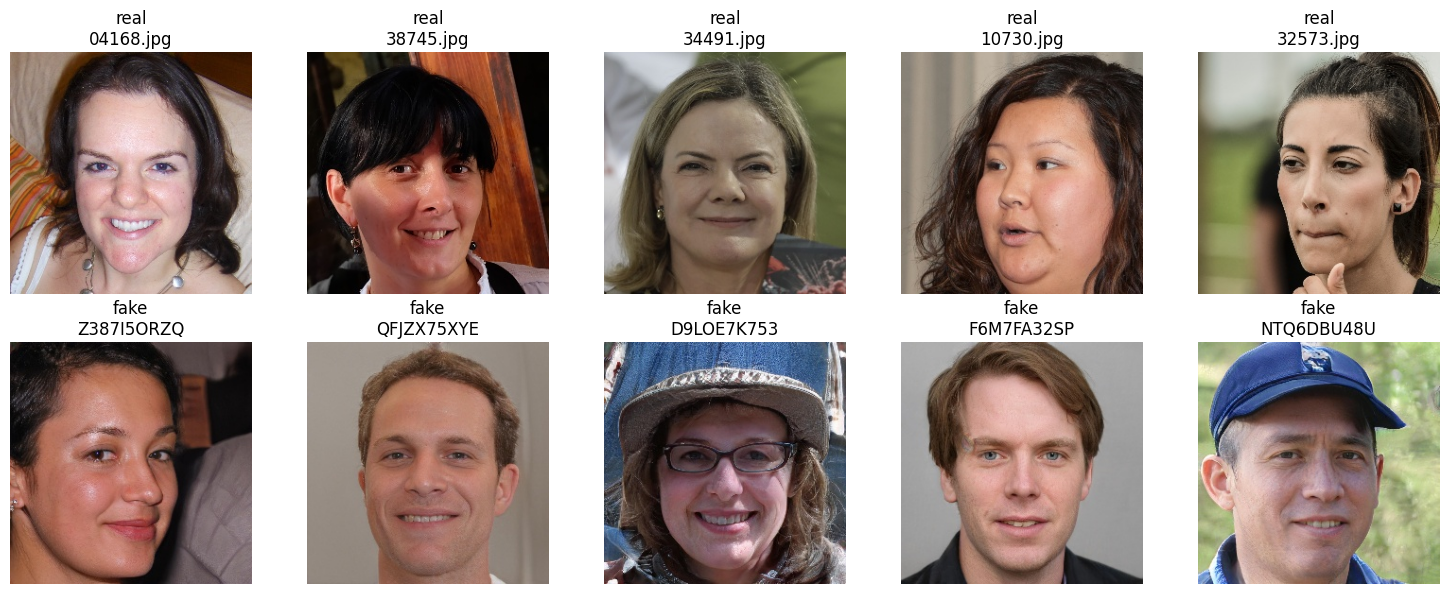

=== Class Distribution ===
Train: real=3500, fake=3500
Val:   real=750, fake=750
Test:  real=750, fake=750


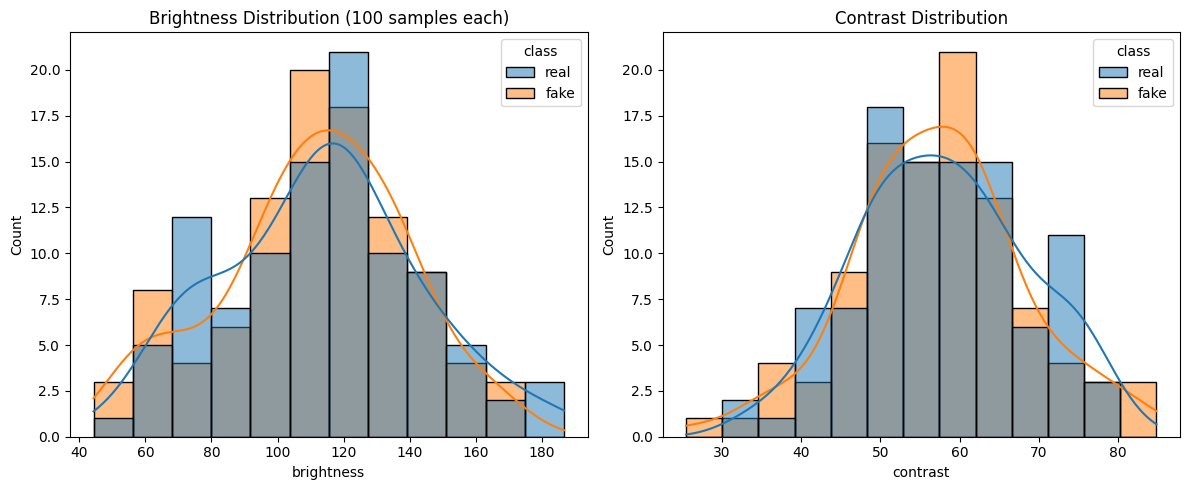


=== Duplicate Image Check (using pixel hashing) ===
Number of duplicate images in train set: 0


In [4]:
# -------------------------------
# 2. Enhanced Data Visualization & EDA
# -------------------------------
# Show sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, cls in enumerate(["real", "fake"]):
    class_dir = os.path.join(train_dir, cls)
    samples = os.listdir(class_dir)[:5]
    for j, sample in enumerate(samples):
        img = plt.imread(os.path.join(class_dir, sample))
        axes[i*5 + j].imshow(img)
        axes[i*5 + j].set_title(f"{cls}\n{sample[:10]}")
        axes[i*5 + j].axis("off")
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

# Class distribution
train_real = len(os.listdir(os.path.join(train_dir, "real")))
train_fake = len(os.listdir(os.path.join(train_dir, "fake")))
val_real = len(os.listdir(os.path.join(valid_dir, "real")))
val_fake = len(os.listdir(os.path.join(valid_dir, "fake")))
test_real = len(os.listdir(os.path.join(test_dir, "real")))
test_fake = len(os.listdir(os.path.join(test_dir, "fake")))

print("=== Class Distribution ===")
print(f"Train: real={train_real}, fake={train_fake}")
print(f"Val:   real={val_real}, fake={val_fake}")
print(f"Test:  real={test_real}, fake={test_fake}")

# Image statistics: brightness, contrast
def compute_image_stats(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)
    contrast = np.std(gray)
    return brightness, contrast

stats = []
for cls in ["real", "fake"]:
    class_dir = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_dir)[:100]:  # sample 100 per class
        img_path = os.path.join(class_dir, img_name)
        res = compute_image_stats(img_path)
        if res:
            stats.append((cls, *res))
stats_df = pd.DataFrame(stats, columns=["class", "brightness", "contrast"])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=stats_df, x="brightness", hue="class", kde=True)
plt.title("Brightness Distribution (100 samples each)")
plt.subplot(1,2,2)
sns.histplot(data=stats_df, x="contrast", hue="class", kde=True)
plt.title("Contrast Distribution")
plt.tight_layout()
plt.savefig("image_stats.png")
plt.show()

# Duplicate image check (exact pixel hashing)
print("\n=== Duplicate Image Check (using pixel hashing) ===")
from hashlib import md5

def get_image_hash(img_path):
    with open(img_path, "rb") as f:
        return md5(f.read()).hexdigest()

hashes = {}
dup_count = 0
for cls in ["real", "fake"]:
    class_dir = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_dir):
        h = get_image_hash(os.path.join(class_dir, img_name))
        if h in hashes:
            dup_count += 1
        else:
            hashes[h] = (cls, img_name)
print(f"Number of duplicate images in train set: {dup_count}")

In [5]:
# -------------------------------
# 3. Data Generators with Augmentation
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)


Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [6]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import *
from tensorflow.keras import models, optimizers
import tensorflow as tf

# -------------------------------
# 4. Build Advanced Model (EfficientNet + Transformer)
# -------------------------------
def build_model(input_shape=(224, 224, 3)):
    
    base_model = EfficientNetB4(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze most layers but allow fine-tuning of top layers
    # for layer in base_model.layers[:-50]:
    #     layer.trainable = False
    # for layer in base_model.layers[-50:]:
    #     layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # Transformer block
    embed_dim = 256
    x = Dense(embed_dim, activation="relu")(x)
    x = BatchNormalization()(x)

    x = Reshape((1, embed_dim))(x)
    attention = MultiHeadAttention(num_heads=4, key_dim=64)
    x = attention(x, x)
    x = LayerNormalization()(x)
    x = Flatten()(x)

    # Classification head
    x = Dense(512, activation="selu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)

    x = Dense(128, activation="selu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)

    x = Dense(32, activation="selu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    # 🔥 FINAL OUTPUT (SIGMOID)
    outputs = Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model


model = build_model()

model.summary()

I0000 00:00:1774012298.342035      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 18,601,632 (70.96 MB)

 Trainable params: 18,474,569 (70.47 MB)

 Non-trainable params: 127,063 (496.34 KB)

In [7]:
# # -------------------------------
# # 5. Train with Callbacks
# # -------------------------------
# early_stop = callbacks.EarlyStopping(
#     monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1
# )
# checkpoint = callbacks.ModelCheckpoint(
#     "best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1
# )
# reduce_lr = callbacks.ReduceLROnPlateau(
#     monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=1
# )

# -------------------------------
# 5. Compile Model
# -------------------------------
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# history = model.fit(
#     train_generator,
#     epochs=50,
#     validation_data=val_generator,
#     callbacks=[early_stop, checkpoint, reduce_lr]
# )


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1774012375.334918     187 service.cc:152] XLA service 0x7f8fbc453230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774012375.334961     187 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774012387.833588     187 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-20 13:13:28.049306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:13:28.237377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:13:28.588391: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

  1/219 ━━━━━━━━━━━━━━━━━━━━ 9:09:29 151s/step - accuracy: 0.5000 - loss: 0.8779 - precision: 0.5882 - recall: 0.5263

2026-03-20 13:14:45.758609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:14:45.946277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:14:46.130673: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:14:46.471973: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:14:46.661189: E external/local_xla/xla/stream_

In [ ]:
# -------------------------------
# 6. Evaluation on Test Set
# -------------------------------
model.load_weights("best_model.keras")

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["fake", "real"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["fake", "real"], yticklabels=["fake", "real"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png")
plt.show()

roc_auc = roc_auc_score(y_true, y_pred_proba[:, 1])
print(f"AUROC: {roc_auc:.4f}")

precision, recall, _ = precision_recall_curve(y_true, y_pred_proba[:, 1])
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig("pr_curve.png")
plt.show()

# -------------------------------
# 7. Save Model for Deployment
# -------------------------------
model.save("deepfake_model_saved", save_format="tf")
model.save("deepfake_model.h5")
print("Model saved in SavedModel and H5 format.")